/home/cihat/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Training done


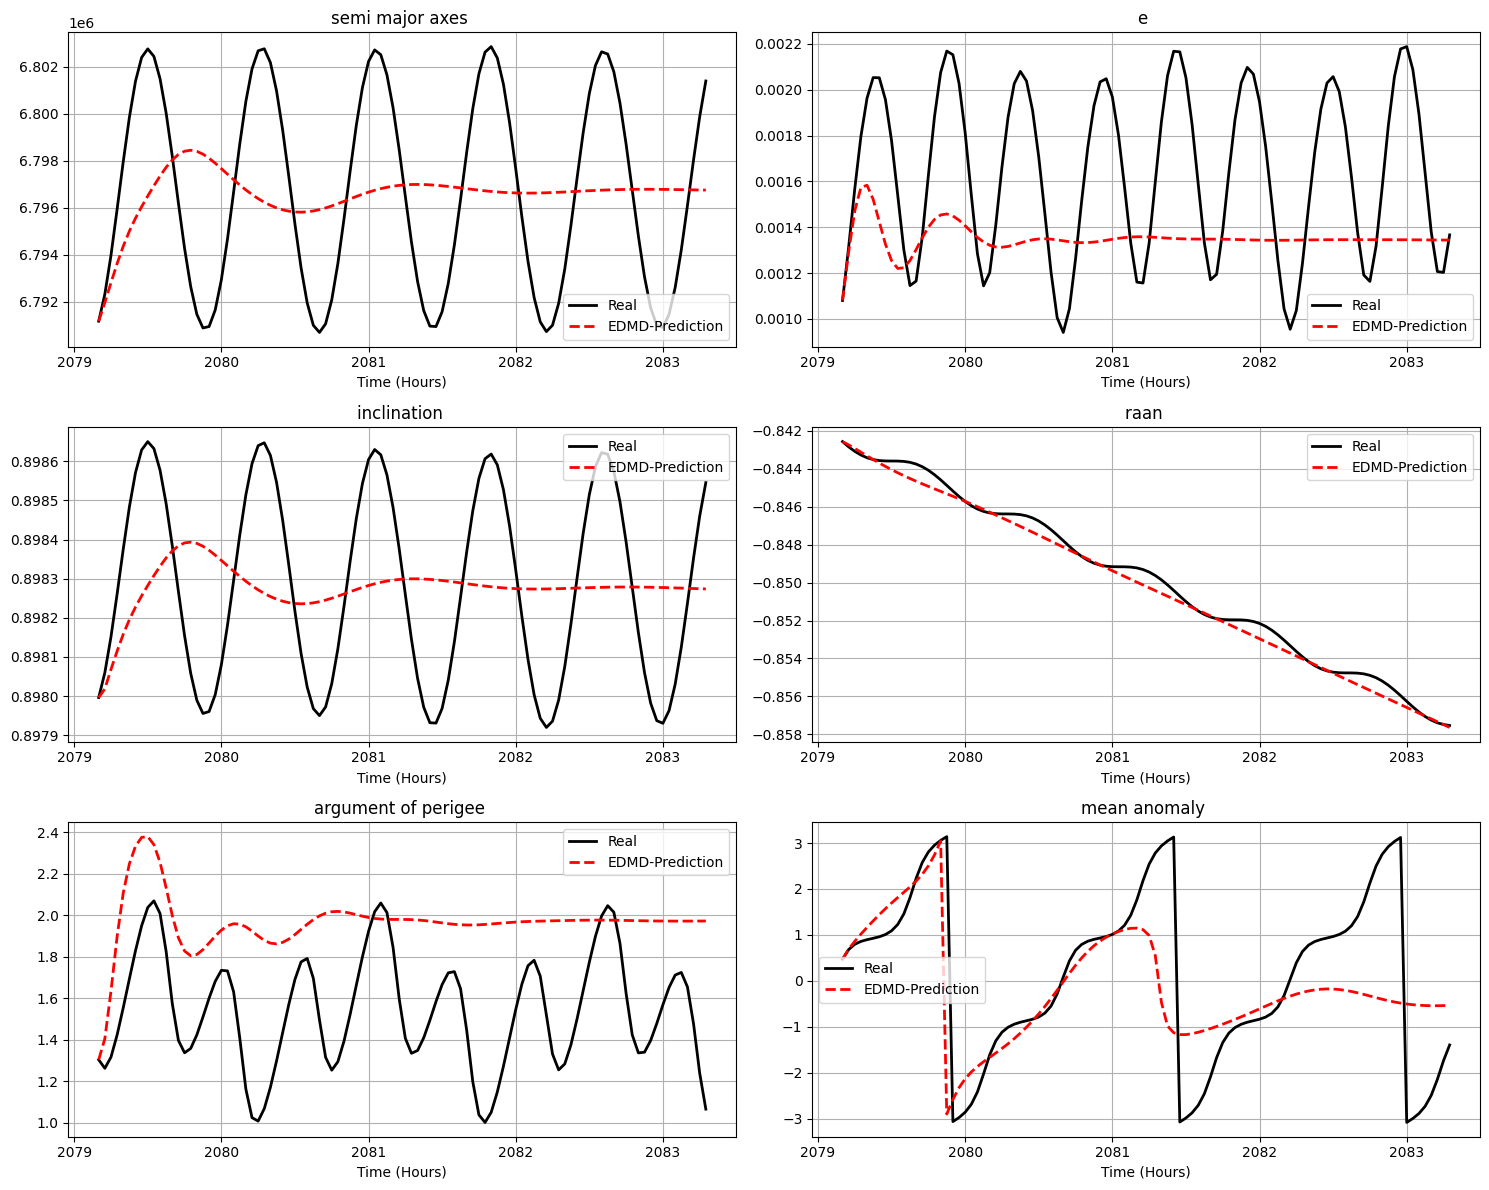

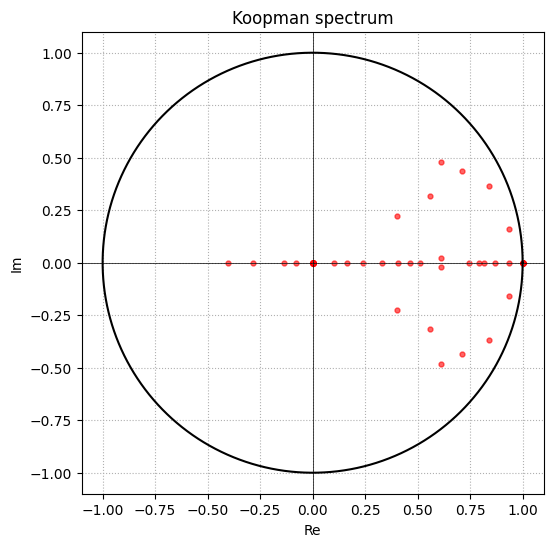

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import eval_legendre
from sklearn.preprocessing import MinMaxScaler
import itertools

DEGREE = 6
TEST_SIZE = 100
EIGEN_THRESHOLD = 0.00

df = pd.read_csv('raw_orbit_data.csv')

train_df = df.iloc[:-TEST_SIZE].copy().reset_index(drop=True)
test_df = df.iloc[-TEST_SIZE:].copy().reset_index(drop=True)

def lift_dataset(df_input, scaler=None, is_train=True):
    df_proc = df_input.copy()
    
    if is_train:
        scaler = MinMaxScaler(feature_range=(-1, 1))
        scaled_ae = scaler.fit_transform(df_proc[['a', 'e']])
    else:
        scaled_ae = scaler.transform(df_proc[['a', 'e']])
        
    math_features = {}
    
    math_features['a'] = scaled_ae[:, 0]
    math_features['e'] = scaled_ae[:, 1]
    
    for angle in ['i', 'raan', 'omega', 'm']:
        math_features[f'sin_{angle}'] = np.sin(df_proc[angle].values)
        math_features[f'cos_{angle}'] = np.cos(df_proc[angle].values)
    
    mu = 3.986004418e14   
    R_e = 6378137.0       
    J2_const = 1.0826e-3  
    
    n_raw = np.sqrt(mu / (df_proc['a'].values**3))
    p_term = df_proc['a'].values * (1 - df_proc['e'].values**2)
    J2_factor = 1.5 * J2_const * (R_e / p_term)**2 * n_raw
    
    math_features['mean_motion_n'] = n_raw
   
    for col in ['a', 'e']:
        x = math_features[col]
        for d in range(2, DEGREE + 1):
            math_features[f"{col}_P{d}"] = eval_legendre(d, x)
            
    for angle in ['i', 'raan', 'omega', 'm']:
        s_val = math_features[f'sin_{angle}']
        c_val = math_features[f'cos_{angle}']
        for d in range(2, DEGREE + 1):
            math_features[f"sin_{angle}_P{d}"] = eval_legendre(d, s_val)
            math_features[f"cos_{angle}_P{d}"] = eval_legendre(d, c_val)
            
    df_lifted = pd.DataFrame(math_features)
    
    base_cols = ['a', 'e', 'sin_i', 'cos_i', 'sin_raan', 'cos_raan', 'sin_omega', 'cos_omega', 'sin_m', 'cos_m']
    cols = base_cols + [c for c in df_lifted.columns if c not in base_cols]
    
    return df_lifted[cols], scaler

X_train_lifted, fitted_scaler = lift_dataset(train_df, is_train=True)

X = X_train_lifted.iloc[:-1].values.T
Y = X_train_lifted.iloc[1:].values.T

K_raw = Y @ np.linalg.pinv(X, rcond=1e-4)

eigenvalues, eigenvectors = np.linalg.eig(K_raw)

valid_indices = np.abs(eigenvalues) >= EIGEN_THRESHOLD
valid_eigenvalues = eigenvalues[valid_indices]
valid_eigenvectors = eigenvectors[:, valid_indices]

Lambda = np.diag(valid_eigenvalues)
K = np.real(valid_eigenvectors @ Lambda @ np.linalg.pinv(valid_eigenvectors))

print("Training done")

first_test_row = test_df.iloc[[0]] 
X_initial_lifted, _ = lift_dataset(first_test_row, scaler=fitted_scaler, is_train=False)

z = X_initial_lifted.values[0] 

predictions_continuous = []
for _ in range(TEST_SIZE):
    predictions_continuous.append(z[:10]) 
    z = K @ z 

predictions_continuous = np.array(predictions_continuous)

a_e_pred = fitted_scaler.inverse_transform(predictions_continuous[:, :2])
a_pred = a_e_pred[:, 0]
e_pred = a_e_pred[:, 1]

i_pred     = np.arctan2(predictions_continuous[:, 2], predictions_continuous[:, 3])
raan_pred  = np.arctan2(predictions_continuous[:, 4], predictions_continuous[:, 5])
omega_pred = np.arctan2(predictions_continuous[:, 6], predictions_continuous[:, 7])
m_pred     = np.arctan2(predictions_continuous[:, 8], predictions_continuous[:, 9])

final_predictions = np.column_stack((a_pred, e_pred, i_pred, raan_pred, omega_pred, m_pred))

actuals = test_df[['a', 'e', 'i', 'raan', 'omega', 'm']].values
time_steps = test_df['t_hours'].values


# Keplerian values graphs
states = ['semi major axes', 'e', 'inclination', 'raan', 'argument of perigee', 'mean anomaly']
fig1, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, state in enumerate(states):
    axes[i].plot(time_steps, actuals[:, i], 'k-', linewidth=2, label='Real')
    axes[i].plot(time_steps, final_predictions[:, i], 'r--', linewidth=2, label='EDMD-Prediction')
    axes[i].set_title(f'{state} ')
    axes[i].set_xlabel('Time (Hours)')
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()

# Eigen values graph
fig2, (ax_eig1) = plt.subplots(1, figsize=(14, 6))

theta = np.linspace(0, 2 * np.pi, 200)

ax_eig1.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1.5)
ax_eig1.scatter(np.real(valid_eigenvalues), np.imag(valid_eigenvalues), color='red', marker='.', s=50, alpha=0.6)
ax_eig1.set_title(f'Koopman spectrum')
ax_eig1.set_xlabel('Re')
ax_eig1.set_ylabel('Im')
ax_eig1.axhline(0, color='black', linewidth=0.5)
ax_eig1.axvline(0, color='black', linewidth=0.5)
ax_eig1.grid(True, linestyle=':')
ax_eig1.set_aspect('equal', adjustable='box') 

plt.show()